<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Project-4/Spotify_Pass_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 4: Spotify Music Popularity Prediction


##Problem Definition


This is a **Supervised** **Regression** problem and we'll be using the tree-based regression model to make the predictions on how **popular** a song will be. We'll also be using Random Forest and XGBoost ***regularization techniques to reduce overfitting and for feature selection.*** Our performance metric will be Cross-validated Root Mean Squared Error (**RMSE**).

##Data Collection

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
#Set the URL
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [ ]:
df = pd.read_csv(url)
df

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F


##Data Cleaning

In [ ]:
df.shape

(1556, 23)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Index,1556.0,778.500000,449.322824,1.0,389.75,778.5,1167.25,1556.0
Highest Charting Position,1556.0,87.744216,58.147225,1.0,37.00,80.0,137.00,200.0
Number of Times Charted,1556.0,10.668380,16.360546,1.0,1.00,4.0,12.00,142.0


In [ ]:
df.isnull().sum()*1000

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


###Target

Possible targets:
- Streams
- Popularity 1-100

Other possible (but not likely) targets:
- Highest Charting Position
- Number of Times Charted
- Week of Highest Charting
- Weeks Charted

In [ ]:
target = 'Streams'

In [ ]:
#View target
df[target].sort_values()

,Streams
1380,"10,016,907"
479,"10,024,729"
48,"10,032,746"
1278,"10,058,303"
1487,"10,086,930"
...,...
633,"9,882,989"
257,"9,889,197"
1197,"9,904,749"
1330,"9,974,143"


In [ ]:
#Look to see if there are nulls in target
df[target].isnull().sum()

np.int64(0)

In [ ]:
#Check the dtype
df[target].dtype

dtype('O')

In [ ]:
df[target] = df[target].str.replace(',', '').astype(int)

In [ ]:
df[target].dtype

dtype('int64')

In [ ]:
df[target]

,Streams
0,48633449
1,47248719
2,40162559
3,37799456
4,33948454
...,...
1551,4630675
1552,4623030
1553,4620876
1554,4607385


In [ ]:
df[target].isnull().sum()

np.int64(0)

In [ ]:
df[target].describe().transpose()

,Streams
count,1.556000e+03
mean,6.340219e+06
std,3.369479e+06
min,4.176083e+06
25%,4.915322e+06
50%,5.275748e+06
75%,6.455044e+06
max,4.863345e+07


###Rows

In [ ]:
#Rows with nulls
df.isnull().any(axis = 1).sum()

np.int64(0)

In [ ]:
#Missing rows
df.isnull().sum().sort_values()

,0
Index,0
Highest Charting Position,0
Number of Times Charted,0
Week of Highest Charting,0
Song Name,0
Streams,0
Artist,0
Artist Followers,0
Song ID,0
Genre,0


In [ ]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

###Columns

Drop Unique IDs
- Index
- Song ID

Remove unknown variables (possible targets)
- Week of Highest Charting
- Popularity
- Streams
- Weeks Charted
- Highest Charting Position
- Number of Times Charted

INT
- Artist Followers
- INT Duration (ms)

Flt
- Energy
- Loudness
- Speechiness
- Acousticness
- Liveness
- Tempo
- Danceability
- Valence

Categorical
- Chord  
- Genre

All categor objects (predictor candidates)
- Song Name
- Artist
- Release Date




In [ ]:
drop_cols = [
    'Index',
    'Song ID',
    'Week of Highest Charting',
    'Popularity',
    'Streams',
    'Weeks Charted',
    'Highest Charting Position',
    'Number of Times Charted',
    'Song Name',
    'Artist',
    'Release Date',
    'Chord'
]

In [ ]:
features = df.drop(columns=drop_cols)
features

,Artist Followers,Genre,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
0,3377762,"['indie rock italiano', 'italian pop']",0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589
1,2230022,['australian hip hop'],0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478
2,6266514,['pop'],0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688
3,83293380,"['pop', 'uk pop']",0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591
4,5473565,"['lgbtq+ hip hop', 'pop rap']",0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894
...,...,...,...,...,...,...,...,...,...,...,...
1551,27167675,"['dance pop', 'pop', 'uk pop']",0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608
1552,15019109,"['sertanejo', 'sertanejo universitario']",0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714
1553,22698747,"['dance pop', 'electropop', 'pop', 'post-teen ...",0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394
1554,208630,"['brega funk', 'funk carioca']",0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881


####Integers

In [ ]:
integer = 'Artist Followers'

In [ ]:
df[integer].sort_values(ascending=True)

,Artist Followers
876,
464,
654,
636,
35,
...,...
863,9949044
856,9949044
228,9987114
1067,9998991


In [ ]:
df[integer] = pd.to_numeric(
  df[integer],
  errors='coerce'
)

df[integer].sort_values(ascending=True)

,Artist Followers
632,4883.0
610,14122.0
149,15889.0
102,16074.0
243,17202.0
...,...
750,NaN
784,NaN
876,NaN
1140,NaN


In [ ]:
df[integer].dtype

dtype('float64')

In [ ]:
df[integer] = df[integer].fillna(0).astype(int)

df[integer].sort_values(ascending=True)

,Artist Followers
876,0
530,0
464,0
654,0
163,0
...,...
529,83337783
548,83337783
1349,83337783
541,83337783


In [ ]:
df[integer].isna().sum()

np.int64(0)

In [ ]:
integer = 'Duration (ms)'

In [ ]:
df[integer].sort_values(ascending=True)

,Duration (ms)
654,
530,
1140,
464,
35,
...,...
391,80081
670,85267
664,86760
260,88625


In [ ]:
df[integer] = pd.to_numeric(
  df[integer],
  errors='coerce'
)

df[integer].sort_values(ascending=True)

,Duration (ms)
1499,30133.0
1030,30583.0
711,37013.0
1137,41867.0
1135,41867.0
...,...
750,NaN
784,NaN
876,NaN
1140,NaN


In [ ]:
df[integer].dtype

dtype('float64')

In [ ]:
df[integer] = df[integer].fillna(0).astype(int)

df[integer].sort_values(ascending=True)

,Duration (ms)
1538,0
530,0
464,0
1140,0
163,0
...,...
274,393280
1335,457592
757,484147
265,515865


In [ ]:
df[integer].isna().sum()

np.int64(0)

####Floats

In [ ]:
floats = [
  'Energy',
  'Loudness',
  'Speechiness',
  'Acousticness',
  'Liveness',
  'Tempo',
  'Danceability',
  'Valence'
]

In [ ]:
df[floats] = df[floats].apply(pd.to_numeric, errors='coerce')
df[floats]

,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Danceability,Valence
0,0.800,-4.808,0.0504,0.12700,0.3590,134.002,0.714,0.589
1,0.764,-5.484,0.0483,0.03830,0.1030,169.928,0.591,0.478
2,0.664,-5.044,0.1540,0.33500,0.0849,166.928,0.563,0.688
3,0.897,-3.712,0.0348,0.04690,0.3640,126.026,0.808,0.591
4,0.704,-7.409,0.0615,0.02030,0.0501,149.995,0.736,0.894
...,...,...,...,...,...,...,...,...
1551,0.700,-6.021,0.0694,0.00261,0.1530,116.073,0.762,0.608
1552,0.870,-3.123,0.0851,0.24000,0.3330,152.370,0.528,0.714
1553,0.523,-4.333,0.0300,0.18400,0.1320,104.988,0.765,0.394
1554,0.550,-7.026,0.0587,0.24900,0.1820,154.064,0.832,0.881


In [ ]:
df[floats].dtypes

,0
Energy,float64
Loudness,float64
Speechiness,float64
Acousticness,float64
Liveness,float64
Tempo,float64
Danceability,float64
Valence,float64


In [ ]:
df[floats].isnull().sum()

,0
Energy,11
Loudness,11
Speechiness,11
Acousticness,11
Liveness,11
Tempo,11
Danceability,11
Valence,11


In [ ]:
df[floats].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Energy,1545.0,0.633495,0.161577,0.054000,0.5320,0.6420,0.752,0.970
Loudness,1545.0,-6.348474,2.509281,-25.166000,-7.4910,-5.9900,-4.711,1.509
Speechiness,1545.0,0.123656,0.110383,0.023200,0.0456,0.0765,0.165,0.884
Acousticness,1545.0,0.248695,0.250326,0.000025,0.0485,0.1610,0.388,0.994
Liveness,1545.0,0.181202,0.144071,0.019700,0.0966,0.1240,0.217,0.962
Tempo,1545.0,122.811023,29.591088,46.718000,97.9600,122.0120,143.860,205.272
Danceability,1545.0,0.689997,0.142444,0.150000,0.5990,0.7070,0.796,0.980
Valence,1545.0,0.514704,0.227326,0.032000,0.3430,0.5120,0.691,0.979


In [ ]:
df[df[floats].isnull().any(axis=1)]

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
35,36,36,1,2021-07-23--2021-07-30,NOT SOBER (feat. Polo G & Stunna Gambino),11869336,The Kid LAROI,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
163,164,5,39,2020-10-30--2020-11-06,34+35,5453159,Ariana Grande,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
464,465,118,1,2021-03-26--2021-04-02,Richer (feat. Polo G),6292362,Rod Wave,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
530,531,20,5,2021-01-15--2021-01-22,"34+35 Remix (feat. Doja Cat, Megan Thee Stalli...",6162453,Ariana Grande,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
636,637,22,6,2020-12-18--2020-12-25,Driving Home for Christmas - 2019 Remaster,8804531,Chris Rea,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
654,655,73,1,2020-12-18--2020-12-25,Thank God It's Christmas - Non-Album Single,10509961,Queen,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
750,751,19,20,2020-07-31--2020-08-07,"Agua (with J Balvin) - Music From ""Sponge On T...",5358940,Tainy,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
784,785,76,14,2020-09-04--2020-09-11,"Lean (feat. Towy, Osquel, Beltito & Sammy & Fa...",4739241,"Super Yei, Jone Quest",0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
876,877,164,4,2020-09-18--2020-09-25,+Linda,4964708,Dalex,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
1140,1141,131,1,2020-05-29--2020-06-05,In meinem Benz,5494500,"AK AUSSERKONTROLLE, Bonez MC",0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,


In [ ]:
df[df[floats].isnull().all(axis=1)]

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
35,36,36,1,2021-07-23--2021-07-30,NOT SOBER (feat. Polo G & Stunna Gambino),11869336,The Kid LAROI,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
163,164,5,39,2020-10-30--2020-11-06,34+35,5453159,Ariana Grande,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
464,465,118,1,2021-03-26--2021-04-02,Richer (feat. Polo G),6292362,Rod Wave,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
530,531,20,5,2021-01-15--2021-01-22,"34+35 Remix (feat. Doja Cat, Megan Thee Stalli...",6162453,Ariana Grande,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
636,637,22,6,2020-12-18--2020-12-25,Driving Home for Christmas - 2019 Remaster,8804531,Chris Rea,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
654,655,73,1,2020-12-18--2020-12-25,Thank God It's Christmas - Non-Album Single,10509961,Queen,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
750,751,19,20,2020-07-31--2020-08-07,"Agua (with J Balvin) - Music From ""Sponge On T...",5358940,Tainy,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
784,785,76,14,2020-09-04--2020-09-11,"Lean (feat. Towy, Osquel, Beltito & Sammy & Fa...",4739241,"Super Yei, Jone Quest",0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
876,877,164,4,2020-09-18--2020-09-25,+Linda,4964708,Dalex,0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,
1140,1141,131,1,2020-05-29--2020-06-05,In meinem Benz,5494500,"AK AUSSERKONTROLLE, Bonez MC",0,,,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,


####Imputation

In [ ]:
df[floats] = df[floats].fillna(0)

In [ ]:
df[floats].isnull().sum()

,0
Energy,0
Loudness,0
Speechiness,0
Acousticness,0
Liveness,0
Tempo,0
Danceability,0
Valence,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Index                      1556 non-null   int64  
 1   Highest Charting Position  1556 non-null   int64  
 2   Number of Times Charted    1556 non-null   int64  
 3   Week of Highest Charting   1556 non-null   object 
 4   Song Name                  1556 non-null   object 
 5   Streams                    1556 non-null   int64  
 6   Artist                     1556 non-null   object 
 7   Artist Followers           1556 non-null   int64  
 8   Song ID                    1556 non-null   object 
 9   Genre                      1556 non-null   object 
 10  Release Date               1556 non-null   object 
 11  Weeks Charted              1556 non-null   object 
 12  Popularity                 1556 non-null   object 
 13  Danceability               1556 non-null   float

In [ ]:
df_obj = df.select_dtypes(include=['object'])
df_obj

,Week of Highest Charting,Song Name,Artist,Song ID,Genre,Release Date,Weeks Charted,Popularity,Chord
0,2021-07-23--2021-07-30,Beggin',Måneskin,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",2017-12-08,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,100,B
1,2021-07-23--2021-07-30,STAY (with Justin Bieber),The Kid LAROI,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],2021-07-09,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,C#/Db
2,2021-06-25--2021-07-02,good 4 u,Olivia Rodrigo,4ZtFanR9U6ndgddUvNcjcG,['pop'],2021-05-21,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,99,A
3,2021-07-02--2021-07-09,Bad Habits,Ed Sheeran,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",2021-06-25,2021-07-23--2021-07-30\n2021-07-16--2021-07-23...,98,B
4,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),Lil Nas X,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,2021-07-23--2021-07-30,96,D#/Eb
...,...,...,...,...,...,...,...,...,...
1551,2019-12-27--2020-01-03,New Rules,Dua Lipa,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",2017-06-02,2019-12-27--2020-01-03,79,A
1552,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,Jorge & Mateus,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",2019-10-11,2019-12-27--2020-01-03,66,B
1553,2019-12-27--2020-01-03,Havana (feat. Young Thug),Camila Cabello,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",2018-01-12,2019-12-27--2020-01-03,81,D
1554,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"Dadá Boladão, Tati Zaqui, OIK",5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",2019-09-25,2019-12-27--2020-01-03,60,F


In [ ]:
df_clean = df.drop(columns=['Index', 'Highest Charting Position', 'Number of Times Charted'])

In [ ]:
df_clean = df_clean.drop(columns=df_obj.columns)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Streams           1556 non-null   int64  
 1   Artist Followers  1556 non-null   int64  
 2   Danceability      1556 non-null   float64
 3   Energy            1556 non-null   float64
 4   Loudness          1556 non-null   float64
 5   Speechiness       1556 non-null   float64
 6   Acousticness      1556 non-null   float64
 7   Liveness          1556 non-null   float64
 8   Tempo             1556 non-null   float64
 9   Duration (ms)     1556 non-null   int64  
 10  Valence           1556 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 133.8 KB


##Exploratory Data Analysis (EDA)

- If Supervised, what data type is your target?  What does that suggest for the type of ML process you will use?
- What is the distribution of values for your target?
- How can/did you discover which fields are Categorical?
- How can/did you discover which fields are Numerical?
- For each field, what is the distribution?
- How can/did you discover the relationship between any two variables?




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

###Correlation

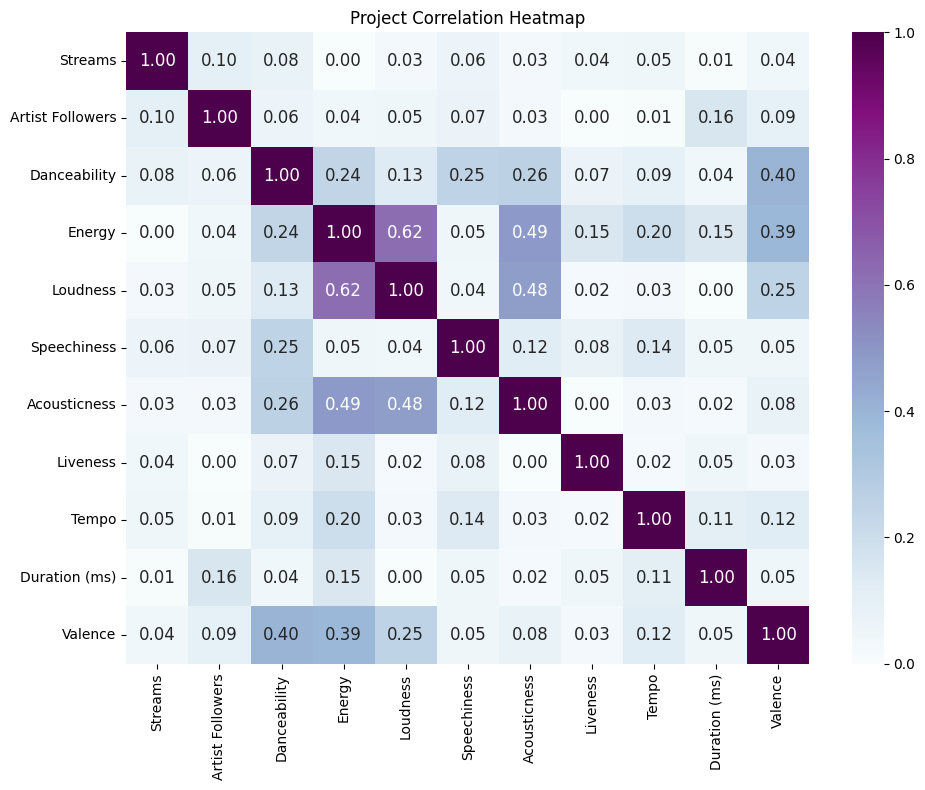

In [ ]:
 corr = df_clean.corr().abs().round(2)

plt.figure(figsize=(10,8))

 sns.heatmap(
    data=corr,
    annot=True, #Turns on the numbers in the boxes
    cmap='BuPu',
    vmin=0,
    vmax=1,
    annot_kws={"size": 12}, #Sets the font size of those numbers to 12
    fmt=".2f" #Formats the numbers to 2 decimal places
)

plt.title("Project Correlation Heatmap") #Update 'Project' with actual project definition

plt.tight_layout()
# plt.savefig("Corr.png")
plt.show()

###Histogram

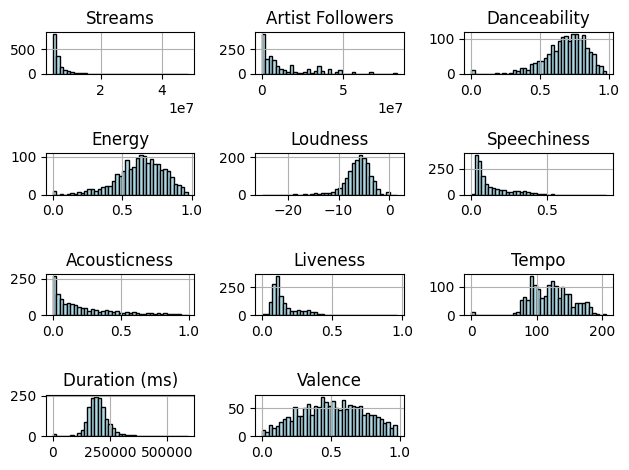

In [ ]:
n = int(1556**(1/2)) # bins

df_clean.hist(bins=n, color='lightblue', edgecolor='black')

plt.tight_layout()
plt.show()

###Boxplot

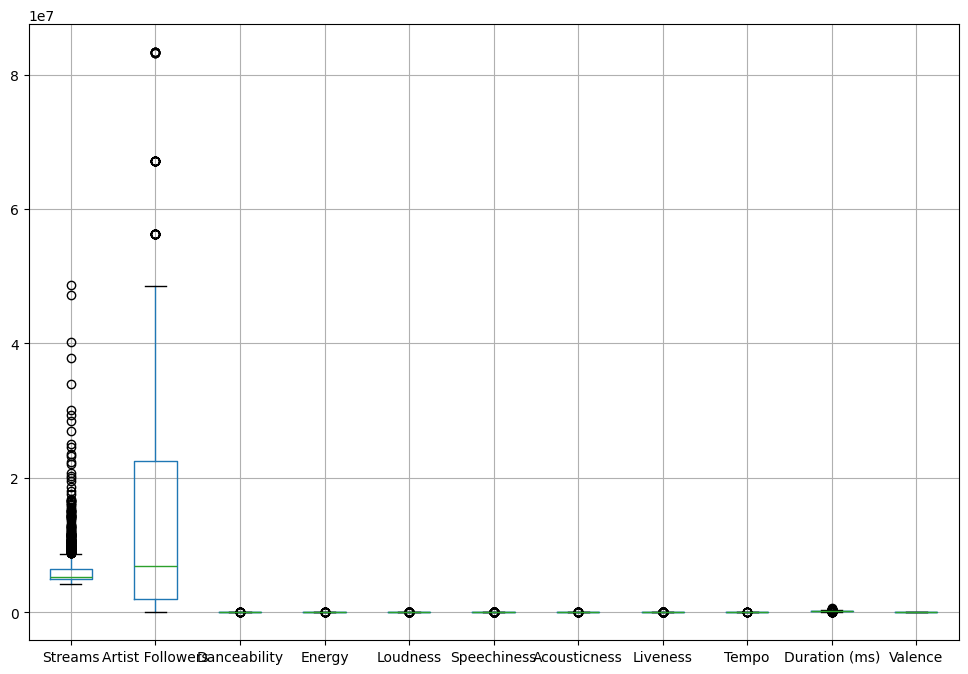

In [ ]:
plt.figure(figsize=(12,8))

df_clean.boxplot()
plt.show()

##Processing
Use modeling techniques to gain useful insights into data and meet objectives of the project.

- What questions did you ask to determine which ML process to use?
- How did/can you determine what performance metric to use?  What others could you have used?  Which metrics might not be appropriate?
- How did/can you account for the variance/bias trade-off?

Models we've learned so far:
- Naive Bayes
- Gaussian Naive Bayes
- Linear Regession
- Ridge Regulation
- Lasso Regulation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

###Decision Tree Regression

In [ ]:
X = df_clean.drop(target, axis = 1)
y = df_clean[target]

In [ ]:
numLoops = 500

rms_error = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3)         # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 3433092940.0


####How do we choose the tree depth?

In [ ]:
max_depths = [1,2,3,4,5,6,7,8,9,10]
rms_depth = np.zeros(len(max_depths))
std_depth = np.zeros(len(max_depths))

numLoops = 500

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std(ddof = 1)

In [ ]:
pd.DataFrame(zip(max_depths, rms_depth, std_depth))

,0,1,2
0,1,3.291270e+06,622556.262598
1,2,3.278948e+06,635808.707335
2,3,3.483984e+06,673624.479999
3,4,3.615050e+06,645048.947369
4,5,3.789582e+06,671168.157199
5,6,4.111196e+06,711591.374260
6,7,4.222793e+06,697849.999768
7,8,4.375621e+06,722014.806248
8,9,4.491740e+06,712743.898302
9,10,4.598870e+06,676421.289693


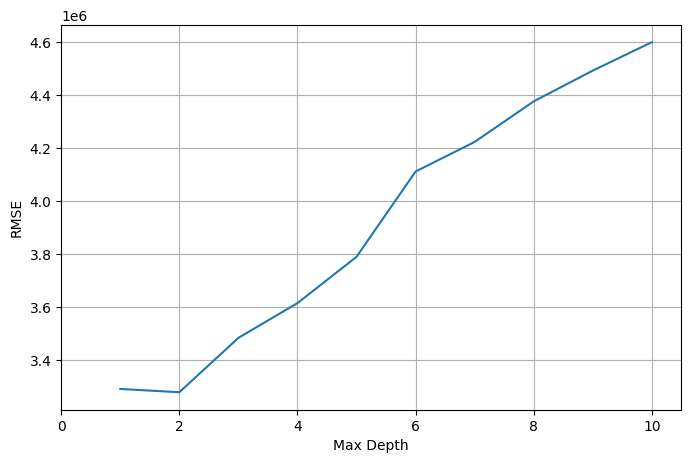

In [ ]:
 #Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()

In [ ]:
#Re run with max depth = 4
numLoops = 500

rms_error = np.zeros(numLoops)

for idx in range(0, numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)*1000}")

CV RMSE: 3625120830.0


####Visualize the Decision Tree

In [ ]:
import graphviz
from IPython.display import display
from sklearn import tree

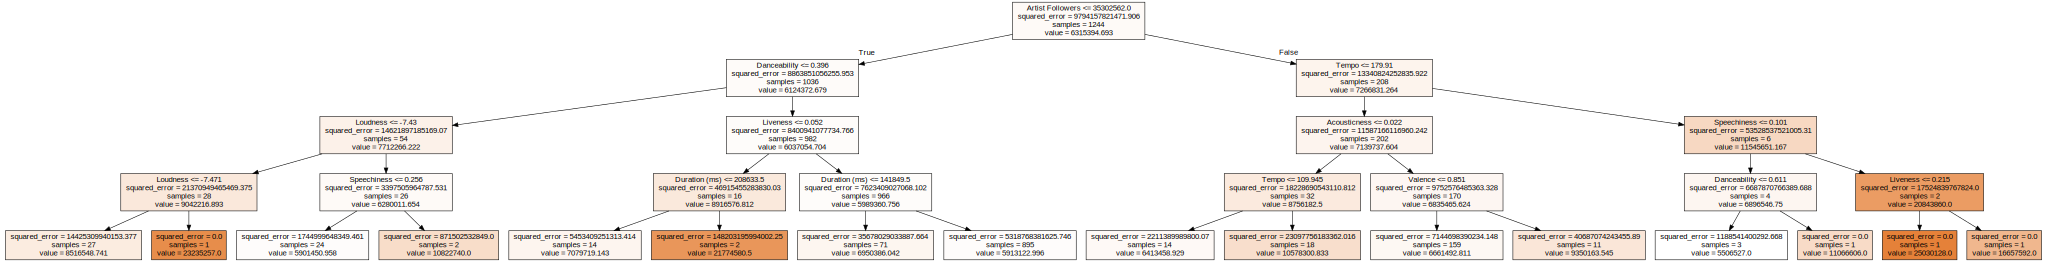

In [ ]:
#Readable view
display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )
  )
)

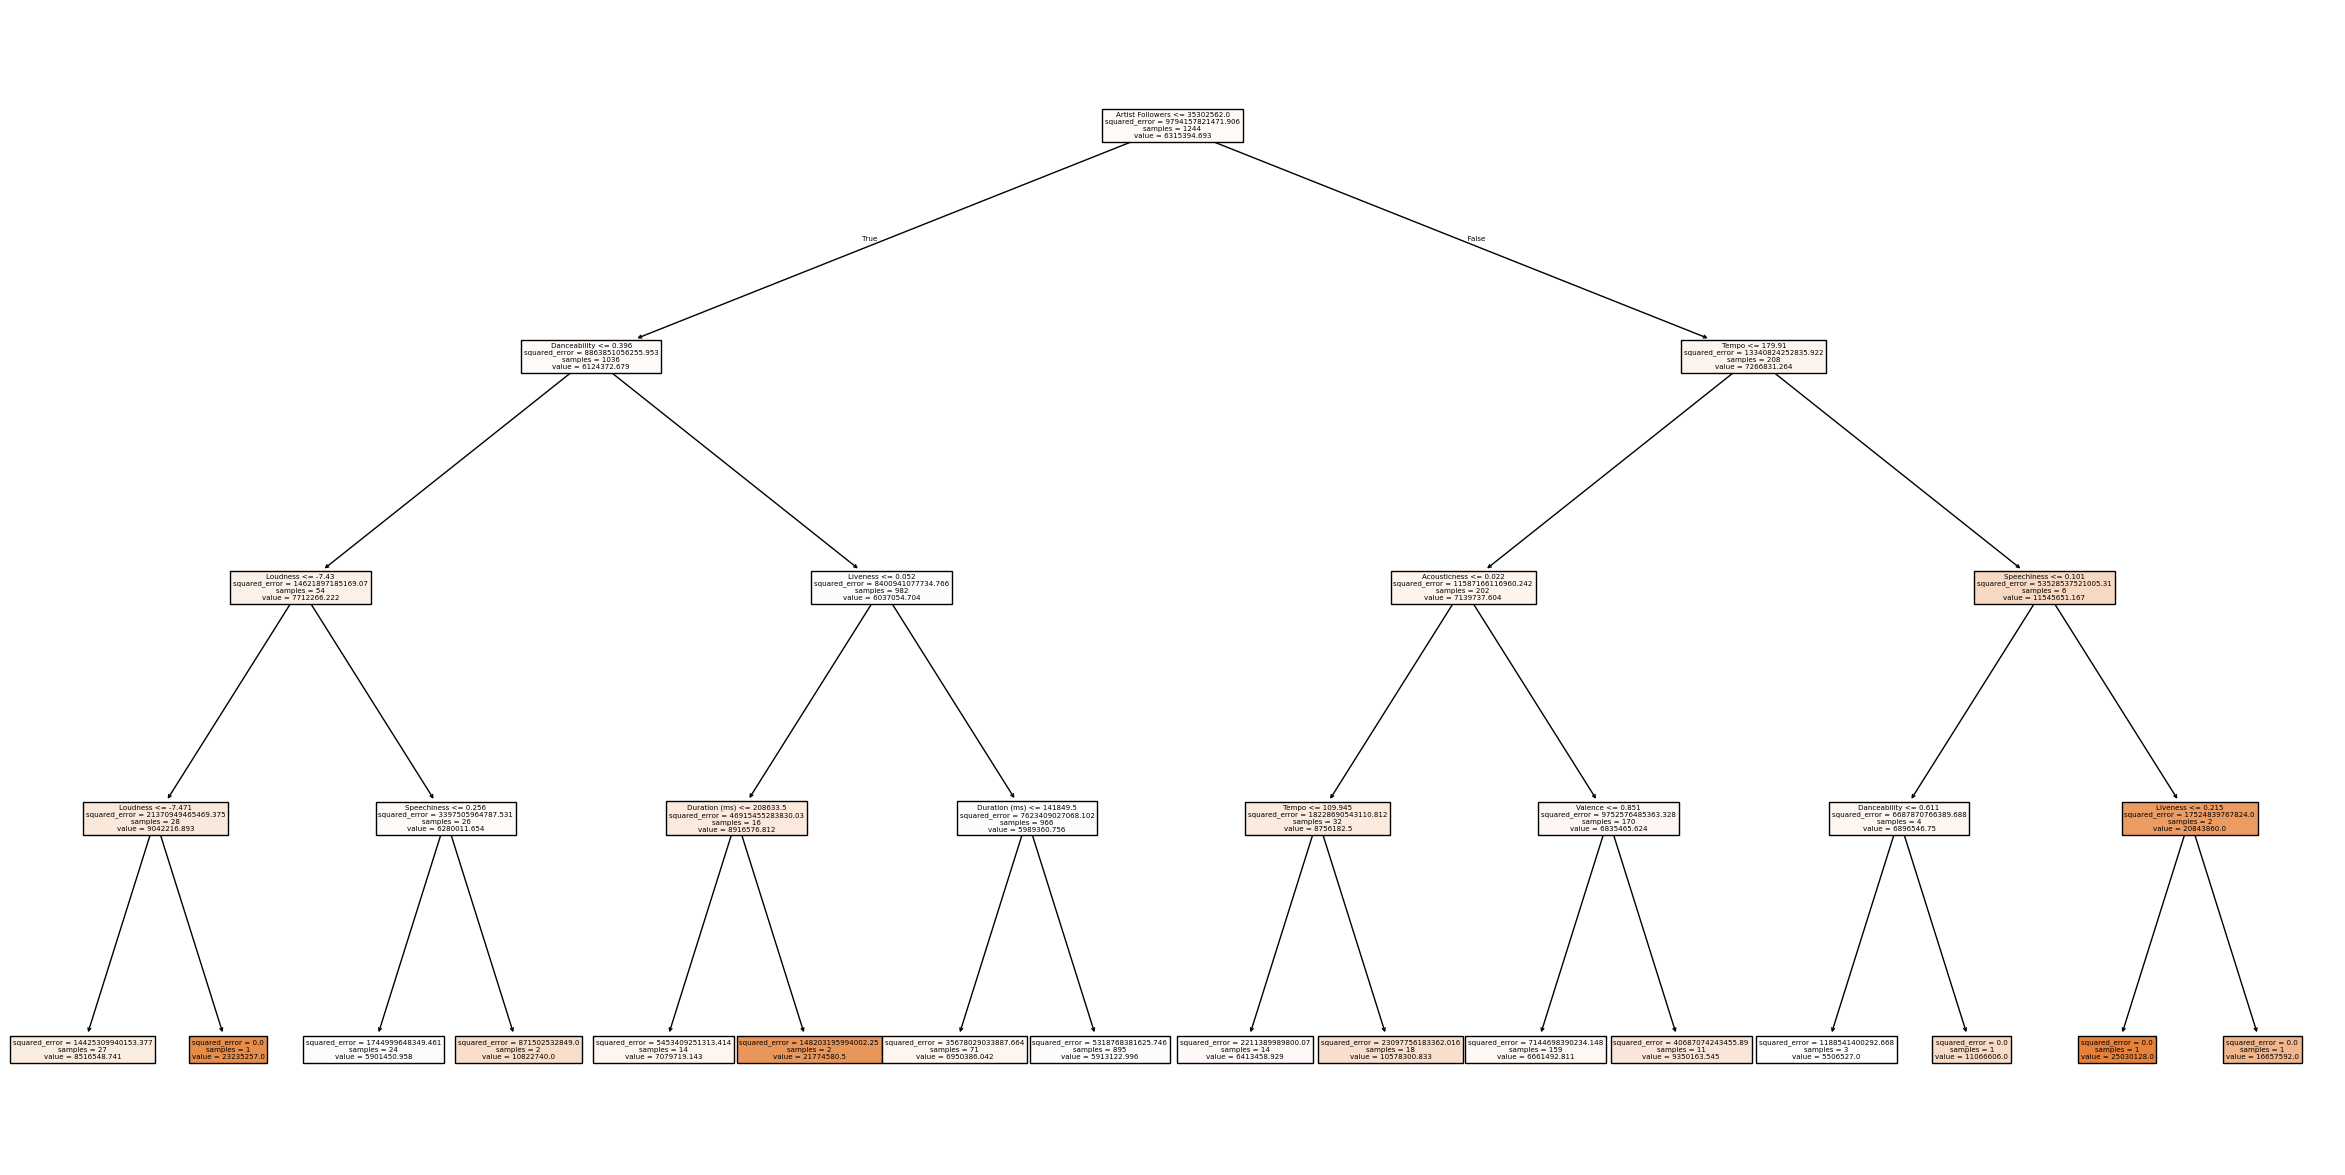

In [ ]:
#Full view
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)

###Random Tree

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import pickle

In [ ]:
#This line intentionally left blank
numLoops = 500

mean_error = np.zeros(numLoops)

np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4, random_state=0)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()*1000}')
print(f'RMSE_std: {np.sqrt(mean_error).std()*1000}')

RMSE: 3674511352.218611
RMSE_std: 670738997.1158963


In [ ]:
#Two parameters - n_estimators (number of trees), max_depth (number of splits)
numLoops = 500

mean_error = np.zeros(numLoops)

# np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
  model = RandomForestRegressor(n_estimators = 10) # n_estimators is number of trees in forest. Note: you can also choose max_depth for RFs
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()*1000}')
print(f'RMSE_std: {np.sqrt(mean_error).std()*1000}')
np.sqrt(mean_error)[:50]

RMSE: 3622948214.548215
RMSE_std: 553827091.1033783


array([3159155.78377189, 4866749.51669663, 2852570.79099047,
       3234778.49041266, 2988311.80407294, 3893293.06217753,
       5006157.51509181, 3589426.3329069 , 2997447.67774661,
       3408193.66132418, 3663883.77874352, 4043341.75580733,
       4448552.2490223 , 3601007.8576697 , 3201990.97377406,
       3913791.27413753, 2800193.25726509, 3355087.65946194,
       2966164.06048563, 2759262.37879091, 4336561.25815535,
       3286725.55131512, 5027548.04227524, 2472738.87047122,
       4042765.04010286, 3897408.01916362, 4884050.34776467,
       2942370.35697524, 2794839.84017632, 3817872.1166679 ,
       3543594.11605591, 4337432.01170138, 2970574.73976405,
       3224924.63107829, 3314929.15280898, 3438274.55791132,
       3530950.62228643, 3745953.85719788, 2945150.34082675,
       3999660.19693779, 3187075.71268056, 3742434.0163071 ,
       4109053.35701373, 4084393.966056  , 3247078.83809386,
       3277762.04687147, 3707838.34504655, 3710903.03133837,
       4362410.36720967,

####How do you choose number of trees?

In [ ]:
num_trees = range(10,60,10)
cv_loops = 100
rmse_results = np.zeros(len(num_trees))
std_results = np.zeros(len(num_trees))

for n, trees in enumerate(num_trees):
  rmse_cv = np.zeros(cv_loops)
  np.random.seed(42)
  for i in range(cv_loops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)
    rfModel = RandomForestRegressor(n_estimators=trees)
    rfModel.fit(X_train, y_train)
    y_pred_rf = rfModel.predict(X_test)
    rmse_cv[i] = np.sqrt(mean_squared_error(y_test, y_pred_rf))

  print(trees,' trees finished.')
  rmse_results[n] = rmse_cv.mean()
  std_results[n] = rmse_cv.std()

10  trees finished.
20  trees finished.
30  trees finished.
40  trees finished.
50  trees finished.


In [ ]:
pickle.dump(rfModel, open('rfModel.p','wb'))

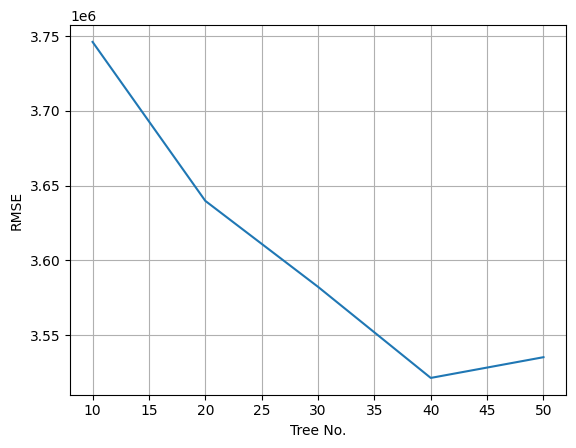

In [ ]:
plt.plot(num_trees, rmse_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.grid()

In [ ]:
pd.DataFrame(zip(num_trees, rmse_results, std_results), columns='depth RMSE STDev'.split())

,depth,RMSE,STDev
0,10,3.746020e+06,531854.495727
1,20,3.639815e+06,594114.403209
2,30,3.582372e+06,634622.132401
3,40,3.521498e+06,595120.965344
4,50,3.535346e+06,566558.821358


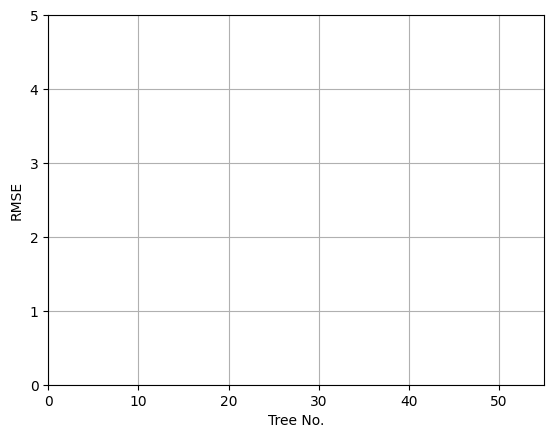

In [ ]:
# plt.errorbar(num_trees, rmse_results, yerr=(std_results*2,std_results*2))
plt.errorbar(num_trees, rmse_results, yerr=std_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.ylim(0,5)
plt.xlim(0,55)
plt.grid()

In [ ]:
print(f'RMSE with 30 trees: {rmse_results[2]*1000}')

RMSE with 30 trees: 3582371827.0462227


In [ ]:
import graphviz
from IPython.display import display
from sklearn import tree

In [ ]:
len(rfModel.estimators_)

50

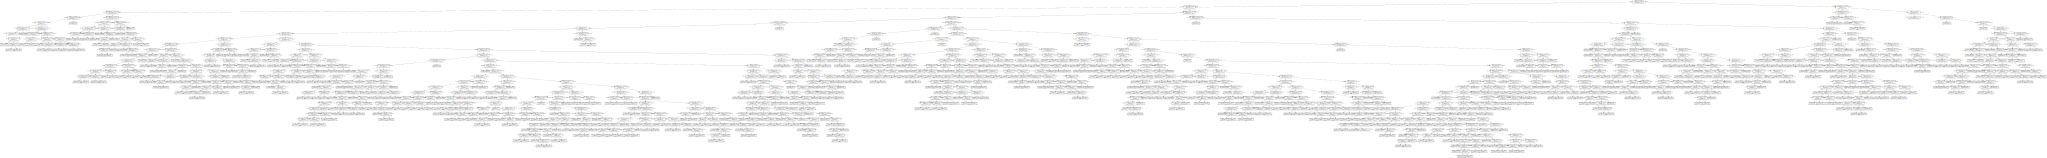

In [ ]:
#Display one tree from the random forest
display(
  graphviz.Source(
    tree.export_graphviz(
      rfModel.estimators_[0],
      feature_names = X.columns,
    )
  )
)

####Find Important Predictors

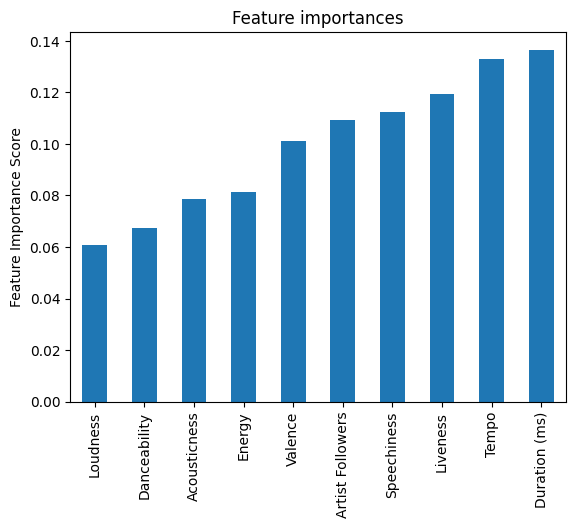

In [ ]:
importances = rfModel.feature_importances_
forest_importances = pd.Series(importances, index = X.columns)

plt.figure()
# forest_importances.plot.bar()
forest_importances.sort_values(ascending=True).plot.bar()
plt.title("Feature importances")
plt.ylabel('Feature Importance Score');

In [ ]:
(forest_importances.sort_values(ascending=False) * 100).cumsum()

,0
Duration (ms),13.659539
Tempo,26.974762
Liveness,38.932483
Speechiness,50.153656
Artist Followers,61.101466
Valence,71.204739
Energy,79.336672
Acousticness,87.183596
Danceability,93.939437
Loudness,100.000000


##Conclusion and Future Work

- Included Random Tree
- Delayed One-Hot encoding for categorical data



Conclusions
  - RMSE went up

Future Work
  - Keep target
  - Looked at feature importances. Keep for now:
    - Duration (ms)
    - Tempo
    - Liveness
  - Test XGB
  - Use One-Hot Encodeing for objects